In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


In [15]:
def generate_data(n_samples=5000, noise=0.05):
    # # Uniform in [-1, 1]^2
    # x = torch.rand(n_samples, 2) * 2 - 1

    # Uniform in [-1.2, 1.2]^2
    x = torch.rand(n_samples, 2) * 2.8 - 1.4
    
    # The Hard Function: High-Frequency Radial Ripple
    # f(x1, x2) = sin(3 * pi * (x1^2 + x2^2))
    radius_squared = x[:, 0]**2 + x[:, 1]**2
    y = torch.sin(3 * torch.pi * radius_squared)
    
    y = y.unsqueeze(1) + noise * torch.randn(n_samples, 1)
    return x, y

x, y = generate_data()

# Create directory one level up
os.makedirs("../data", exist_ok=True)

# Serialize tensors to disk one level up
torch.save(x, "../data/x_data_extra.pt")
torch.save(y, "../data/y_data_extra.pt")

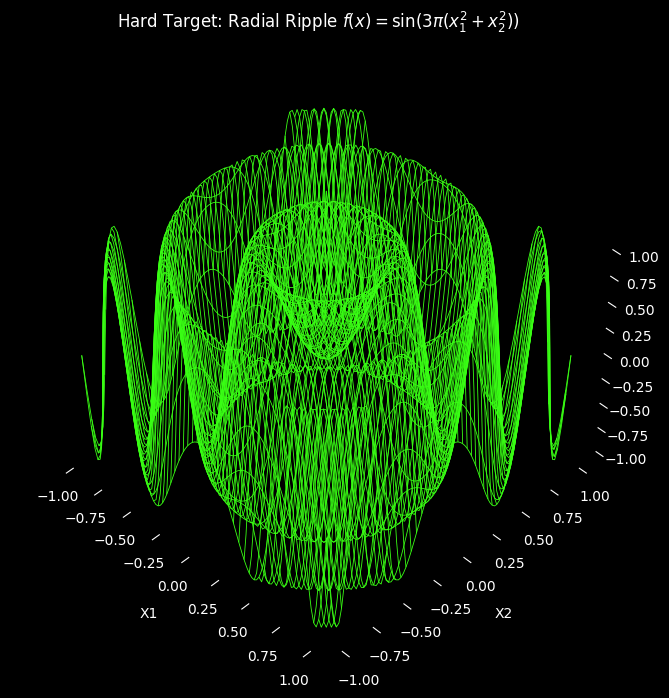

In [16]:


#-----PLOT-----#

# 1. Define the grid space over the domain [-1, 1]^2
x1_vals = np.linspace(-1, 1, 100) # Increased resolution for high-frequency ripples
x2_vals = np.linspace(-1, 1, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# 2. Compute the true function (noiseless)
R2 = X1**2 + X2**2
Y = np.sin(3 * np.pi * R2)

# 3. Configure the aesthetic environment (Black background)
fig = plt.figure(figsize=(10, 8), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')

# 4. Plot the surface as a neon green wireframe
neon_green = '#39FF14'
ax.plot_wireframe(X1, X2, Y, color=neon_green, linewidth=0.6)

# 5. Format axes to maintain the minimalist dark theme
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

ax.grid(False)

ax.tick_params(colors='white')
ax.set_xlabel('X1', color='white', labelpad=10)
ax.set_ylabel('X2', color='white', labelpad=10)
ax.set_zlabel('Y', color='white', labelpad=10)

ax.set_title(r'Hard Target: Radial Ripple $f(x) = \sin(3\pi(x_1^2 + x_2^2))$', color='white', pad=20)

# Adjust viewing angle to look slightly down into the ripples
ax.view_init(elev=45, azim=-45)

plt.show()